# Project 03 (final) — Customer segmentation · reference solution

**Module 05 — Machine Learning 2 · the unsupervised learning capstone**

This reference solution is fully executed. It consolidates the unsupervised part of the module on **real data** (UCI *Wholesale Customers*, 440 wholesale customers of a Portuguese distributor) and answers a concrete business question:

> *The distributor knows its customers only through their annual spending in six product categories. Are there natural customer segments — and if so, how many, what do they look like, and how sure are we?*

We walk the complete path: **EDA → preprocessing → dimensionality reduction (PCA, t-SNE) → four clustering methods (k-means, GMM/EM, DBSCAN, Ward) → model selection (silhouette, BIC, ARI) → business interpretation.**

The decisive didactic point up front: the four methods **partly contradict each other**, and that contradiction is precisely the lesson. There is no "correct" clustering algorithm — there are only assumptions that fit the data or do not.

## 0 · Setup and data

The data are cached locally into `datasets/` (the folder is excluded from the repository via `.gitignore` — we do not commit real data). If the file is already there, nothing is downloaded again; otherwise we fetch it from UCI (with a `User-Agent` header, otherwise the server answers with 406).

The six **continuous** features are the annual spending (in monetary units) on: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.
We keep the two **categorical** columns strictly out of the clustering and save them for the *external validation*:
- `Channel`: 1 = **Horeca** (hotel/restaurant/café), 2 = **retail**
- `Region`: 1 = Lisbon, 2 = Porto, 3 = other

`Channel` is our secret "truth": a good, purely data-driven clustering should rediscover this business logic *without ever having seen it*.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import urllib.request

RNG = 42
np.random.seed(RNG)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_DIR = Path("datasets")
DATA_DIR.mkdir(exist_ok=True)
CSV = DATA_DIR / "wholesale_customers.csv"
URL = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
       "00292/Wholesale%20customers%20data.csv")

if not CSV.exists():
    req = urllib.request.Request(URL, headers={"User-Agent": "Mozilla/5.0"})
    CSV.write_bytes(urllib.request.urlopen(req, timeout=60).read())
    print("downloaded ->", CSV)

df = pd.read_csv(CSV)
FEATURES = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
print("Shape:", df.shape)
df.head()

downloaded -> datasets/wholesale_customers.csv
Shape: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [2]:
# Save the categorical columns as external labels, then keep ONLY the 6 spending columns.
channel = (df["Channel"].values - 1)      # 0 = Horeca, 1 = retail
region  = df["Region"].values
X = df[FEATURES].values.astype(float)
print("Channel distribution:", dict(zip(*np.unique(channel, return_counts=True))))  # 0:298 Horeca, 1:142 retail
df[FEATURES].describe().round(0)

Channel distribution: {np.int64(0): np.int64(298), np.int64(1): np.int64(142)}


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0
mean,12000.0,5796.0,7951.0,3072.0,2881.0,1525.0
std,12647.0,7380.0,9503.0,4855.0,4768.0,2820.0
min,3.0,55.0,3.0,25.0,3.0,3.0
25%,3128.0,1533.0,2153.0,742.0,257.0,408.0
50%,8504.0,3627.0,4756.0,1526.0,816.0,966.0
75%,16934.0,7190.0,10656.0,3554.0,3922.0,1820.0
max,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0


## 1 · EDA: why we do *not* cluster on the raw data

Look at the distributions. All six features are **strongly right-skewed** (median much smaller than the mean, maxima at 10 to 40 times the median). The reason is substantive: spending is multiplicative (a large customer does not spend *100 more*, but *100 times as much*), and multiplicative quantities are typically **log-normally** distributed.

For distance-based methods (k-means, Ward) and density-based methods (DBSCAN) that is fatal: the Euclidean distance is dominated by the few giant customers; a single outlier in `Fresh` outvotes the entire structure in the smaller categories. Hence: a **`log1p` transformation** (which makes the distributions approximately symmetric) **and then standardization** (z-score, so that every category carries the same weight).

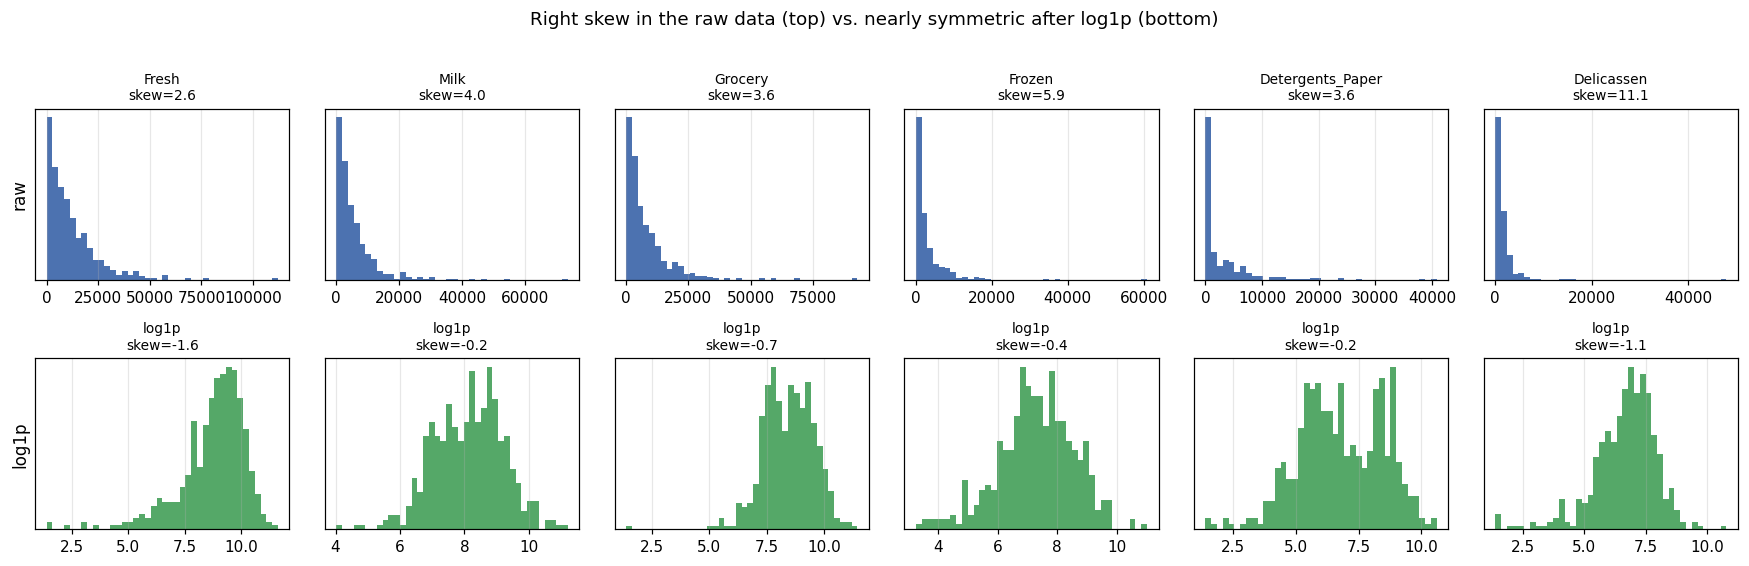

In [3]:
from scipy.stats import skew

fig, axes = plt.subplots(2, 6, figsize=(16, 5))
for j, f in enumerate(FEATURES):
    axes[0, j].hist(X[:, j], bins=40, color="#4C72B0")
    axes[0, j].set_title(f"{f}\nskew={skew(X[:,j]):.1f}", fontsize=9)
    axes[1, j].hist(np.log1p(X[:, j]), bins=40, color="#55A868")
    axes[1, j].set_title(f"log1p\nskew={skew(np.log1p(X[:,j])):.1f}", fontsize=9)
    for r in (0, 1):
        axes[r, j].set_yticks([])
axes[0, 0].set_ylabel("raw", fontsize=11)
axes[1, 0].set_ylabel("log1p", fontsize=11)
fig.suptitle("Right skew in the raw data (top) vs. nearly symmetric after log1p (bottom)", y=1.02)
plt.tight_layout(); plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler

X_log = np.log1p(X)
scaler = StandardScaler()
Xs = scaler.fit_transform(X_log)
print("After log1p+z-score:  mean approx.", Xs.mean(0).round(2), " std approx.", Xs.std(0).round(2))
print("Skewness before (mean over features): %.2f   after: %.2f"
      % (np.mean([skew(X[:,j]) for j in range(6)]),
         np.mean([skew(Xs[:,j]) for j in range(6)])))

After log1p+z-score:  mean approx. [ 0. -0. -0.  0. -0. -0.]  std approx. [1. 1. 1. 1. 1. 1.]
Skewness before (mean over features): 5.13   after: -0.69


## 2 · Dimensionality reduction I: PCA

PCA (script 2.9) looks for the orthogonal directions of maximal variance. Two goals here:
1. **Visualization** in 2D without distorting the global structure (unlike t-SNE).
2. **Interpretation**: the loadings (`components_`) tell us *which* spending categories belong together.

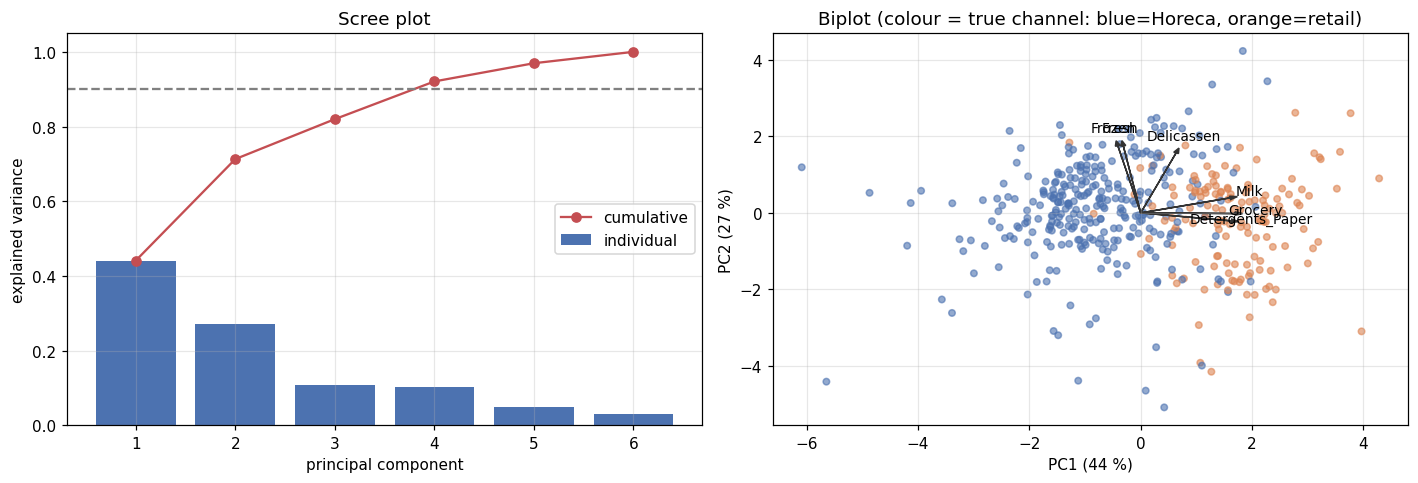

Explained variance, cumulative: [0.441 0.713 0.82  0.921 0.97  1.   ]
PC1 loadings: {'Fresh': np.float64(-0.11), 'Milk': np.float64(0.54), 'Grocery': np.float64(0.57), 'Frozen': np.float64(-0.14), 'Detergents_Paper': np.float64(0.55), 'Delicassen': np.float64(0.21)}
PC2 loadings: {'Fresh': np.float64(0.59), 'Milk': np.float64(0.13), 'Grocery': np.float64(-0.01), 'Frozen': np.float64(0.59), 'Detergents_Paper': np.float64(-0.07), 'Delicassen': np.float64(0.53)}


In [5]:
from sklearn.decomposition import PCA

pca = PCA().fit(Xs)
evr = pca.explained_variance_ratio_
Z = pca.transform(Xs)           # scores

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
a1.bar(range(1, 7), evr, color="#4C72B0", label="individual")
a1.plot(range(1, 7), np.cumsum(evr), "o-", color="#C44E52", label="cumulative")
a1.axhline(0.9, ls="--", c="grey"); a1.set_xlabel("principal component")
a1.set_ylabel("explained variance"); a1.set_title("Scree plot"); a1.legend()

# Biplot: scores (customers) + loading arrows (features), coloured by the TRUE channel
colors = np.where(channel == 0, "#4C72B0", "#DD8452")
a2.scatter(Z[:, 0], Z[:, 1], c=colors, s=18, alpha=0.6)
for j, f in enumerate(FEATURES):
    a2.arrow(0, 0, pca.components_[0, j]*3.2, pca.components_[1, j]*3.2,
             color="#333", head_width=0.09, length_includes_head=True)
    a2.text(pca.components_[0, j]*3.6, pca.components_[1, j]*3.6, f,
            fontsize=9, ha="center", color="black")
a2.set_xlabel(f"PC1 ({evr[0]*100:.0f} %)"); a2.set_ylabel(f"PC2 ({evr[1]*100:.0f} %)")
a2.set_title("Biplot (colour = true channel: blue=Horeca, orange=retail)")
plt.tight_layout(); plt.show()

print("Explained variance, cumulative:", np.cumsum(evr).round(3))
print("PC1 loadings:", dict(zip(FEATURES, pca.components_[0].round(2))))
print("PC2 loadings:", dict(zip(FEATURES, pca.components_[1].round(2))))

**Interpretation of the principal components** (the decisive substantive insight):

- **PC1 (44 % of the variance)** loads strongly and positively on `Milk`, `Grocery`, `Detergents_Paper` (loadings about 0.54–0.57) — the classical **supermarket/retail basket**: durable goods, cleaning products, paper, dairy.
- **PC2 (27 % of the variance)** loads on `Fresh`, `Frozen`, `Delicassen` (about 0.53–0.59) — the **gastronomy basket**: fresh and frozen goods, delicatessen.

The biplot already shows (through the colouring by `Channel`, which the PCA has *never seen*) that Horeca and retail separate along **PC1**: retail customers lie to the right (high grocery/detergents spending). The structure is therefore real and lies in the spending patterns — not in the labels. `Detergents_Paper` is the strongest single separator (a well-known result for this data set).

PC1+PC2 explain **71 %** of the variance — a 2D view loses little.

## 3 · Dimensionality reduction II: t-SNE

t-SNE (script 2.10) preserves **local** neighbourhoods and often separates blobs more cleanly to the eye, but it distorts global distances and cluster sizes — hence *for visualization only*, never as a preprocessing step for clustering and never for interpreting distances. `perplexity` is the most important hyperparameter (the order of magnitude of the neighbourhood taken into account).

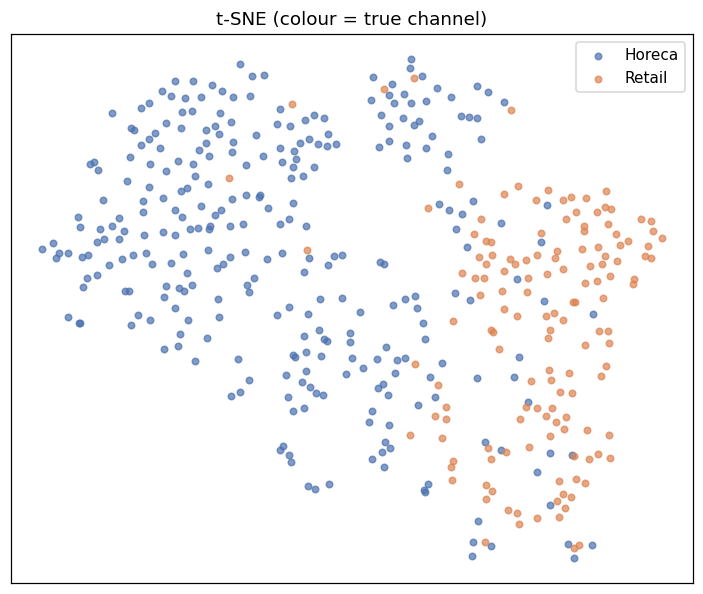

In [6]:
from sklearn.manifold import TSNE

emb = TSNE(n_components=2, perplexity=30, init="pca",
           learning_rate="auto", random_state=RNG).fit_transform(Xs)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for c, name, col in [(0, "Horeca", "#4C72B0"), (1, "Retail", "#DD8452")]:
    m = channel == c
    ax.scatter(emb[m, 0], emb[m, 1], s=18, alpha=0.7, label=name, color=col)
ax.set_title("t-SNE (colour = true channel)"); ax.legend()
ax.set_xticks([]); ax.set_yticks([]); plt.tight_layout(); plt.show()

t-SNE confirms it: there are **no clusters separated by a wide gap**. Horeca and retail form two overlapping clouds with a smooth transition. Remember this picture — it explains later **why DBSCAN must fail** and why the silhouette values stay moderate.

## 4 · k-means: model selection via elbow and silhouette

k-means (script 2.6) minimizes the within-cluster sum of squares and implicitly assumes **spherical, equally large** clusters. We determine $k$ by two criteria:
- **Elbow**: the inertia (WCSS) over $k$ — look for the kink.
- **Silhouette**: the mean silhouette $s(i)=\frac{b(i)-a(i)}{\max(a(i),b(i))}\in[-1,1]$; higher is better, independent of the scale.

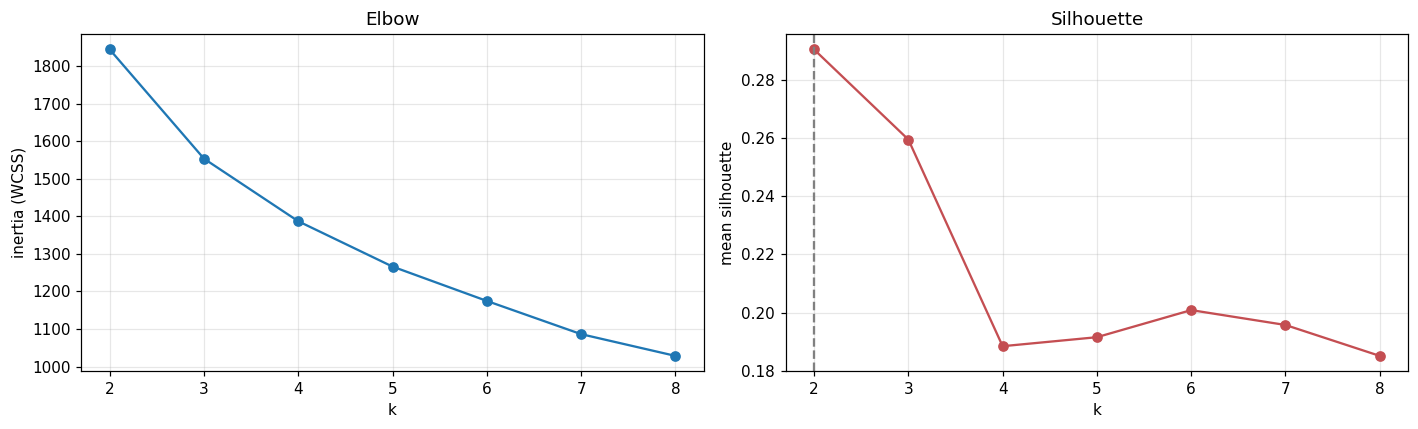

k=2: silhouette=0.290
k=3: silhouette=0.259
k=4: silhouette=0.188
k=5: silhouette=0.192
k=6: silhouette=0.201
k=7: silhouette=0.196
k=8: silhouette=0.185


In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

Ks = range(2, 9)
inertia, sil = [], []
for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RNG).fit(Xs)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Xs, km.labels_))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.plot(list(Ks), inertia, "o-"); a1.set_xlabel("k"); a1.set_ylabel("inertia (WCSS)")
a1.set_title("Elbow")
a2.plot(list(Ks), sil, "o-", color="#C44E52"); a2.set_xlabel("k")
a2.set_ylabel("mean silhouette"); a2.set_title("Silhouette")
a2.axvline(2, ls="--", c="grey")
plt.tight_layout(); plt.show()
for k, s in zip(Ks, sil): print(f"k={k}: silhouette={s:.3f}")

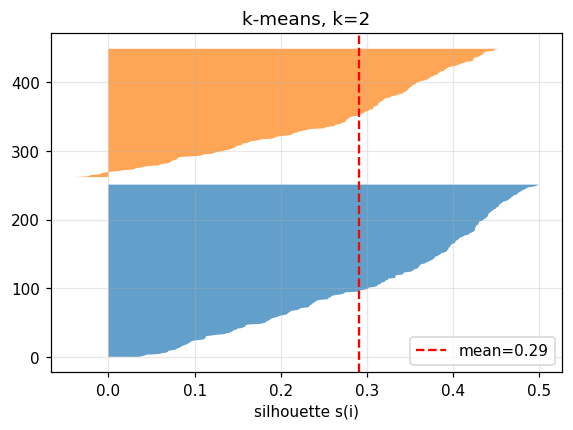

In [8]:
# Silhouette diagram for the chosen solution k=2
km2 = KMeans(n_clusters=2, n_init=10, random_state=RNG).fit(Xs)
sv = silhouette_samples(Xs, km2.labels_)
fig, ax = plt.subplots(figsize=(6, 4)); y = 0
for c in range(2):
    vals = np.sort(sv[km2.labels_ == c])
    ax.fill_betweenx(np.arange(y, y+len(vals)), 0, vals, alpha=0.7)
    y += len(vals) + 10
ax.axvline(sv.mean(), ls="--", c="red", label=f"mean={sv.mean():.2f}")
ax.set_xlabel("silhouette s(i)"); ax.set_title("k-means, k=2"); ax.legend(); plt.show()

The elbow (a weak kink at $k=2$–$3$) and the silhouette (a maximum at **$k=2$**, 0.29) both point to a **coarse two-way split**. The silhouette value of 0.29 is *moderate* — consistent with the t-SNE picture of overlapping clouds. There are no crystal-clear clusters; there is a dominant two-group contrast plus a grey zone.

## 5 · Gaussian mixture / EM: model selection via BIC

The GMM (script 2.7) models the data as a mixture of Gaussian components and delivers **soft** assignments (the responsibilities $\gamma_{ik}$). Unlike k-means it allows, through the covariance matrix, **elliptical, differently sized and rotated** clusters — a good match for our elongated log-normal blobs.

Model selection via the **BIC**: $\mathrm{BIC} = -2\,\ell(\hat\theta) + p\log n$, where $p$ is the number of free parameters. The BIC penalizes complexity and approximates the marginal model evidence — we minimize it **jointly over the number of components and the covariance type**.

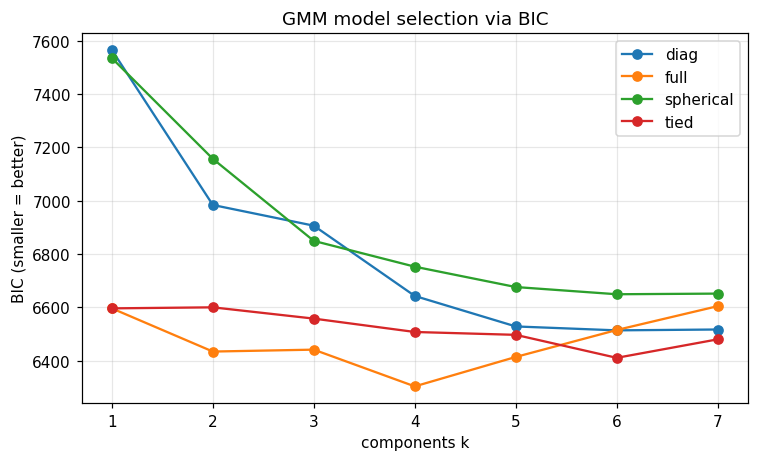

BIC minimum: {'cov': 'full', 'k': 4, 'BIC': 6303.805747507101, 'AIC': 5850.173752819835}


In [9]:
from sklearn.mixture import GaussianMixture

rows = []
for cov in ["full", "tied", "diag", "spherical"]:
    for k in range(1, 8):
        g = GaussianMixture(n_components=k, covariance_type=cov,
                            n_init=5, random_state=RNG).fit(Xs)
        rows.append((cov, k, g.bic(Xs), g.aic(Xs)))
bic = pd.DataFrame(rows, columns=["cov", "k", "BIC", "AIC"])

fig, ax = plt.subplots(figsize=(7, 4.3))
for cov, sub in bic.groupby("cov"):
    ax.plot(sub.k, sub.BIC, "o-", label=cov)
ax.set_xlabel("components k"); ax.set_ylabel("BIC (smaller = better)")
ax.set_title("GMM model selection via BIC"); ax.legend(); plt.tight_layout(); plt.show()

best = bic.loc[bic.BIC.idxmin()]
best_k, best_cov = int(best["k"]), str(best["cov"])
print("BIC minimum:", best.to_dict())

In [10]:
# Two readings: the BIC optimum (fine grained) vs. the coarse 2-segment view
gmm_bic = GaussianMixture(n_components=best_k, covariance_type=best_cov,
                          n_init=5, random_state=RNG).fit(Xs)
gmm2 = GaussianMixture(n_components=2, covariance_type="full",
                       n_init=5, random_state=RNG).fit(Xs)
resp = gmm2.predict_proba(Xs)
print("GMM (k=%d, %s): silhouette=%.3f"
      % (best_k, best_cov, silhouette_score(Xs, gmm_bic.predict(Xs))))
print("Soft assignment, example responsibilities (first 5 customers, k=2):")
print(np.round(resp[:5], 2))
print("Share of 'uncertain' customers (max. responsibility < 0.8): %.1f %%"
      % (100 * np.mean(resp.max(1) < 0.8)))

GMM (k=4, full): silhouette=0.172
Soft assignment, example responsibilities (first 5 customers, k=2):
[[0.98 0.02]
 [0.97 0.03]
 [0.95 0.05]
 [0.   1.  ]
 [0.71 0.29]]
Share of 'uncertain' customers (max. responsibility < 0.8): 6.1 %


**The instructive conflict.** The BIC is minimal at **$k=4$** (covariance type `full`) — statistically there are therefore four Gaussian components (sub-segments, e.g. retail split into "pure supermarkets" vs. "cafés with a shop counter"). The *coarse* two-way split ($k=2$) is however the dominant structure for the business. Both statements are true — they answer different questions ("how many statistical components?" vs. "which main target groups?"). The soft assignment also shows that a noticeable share of the customers (about 6 % here) lies **in the transition** (maximum responsibility < 0.8) — information that a hard assignment (k-means) throws away.

## 6 · DBSCAN: an *instructive failure*

DBSCAN (script 2.8) defines clusters as **dense regions separated by sparsely populated regions**. Parameters: `min_samples` (heuristic: $\ge 2\cdot\dim = 12$) and `eps`, which we choose via the **k-distance plot** (the sorted distance to the 12th nearest neighbour; the "knee" marks the boundary between dense and sparse areas).

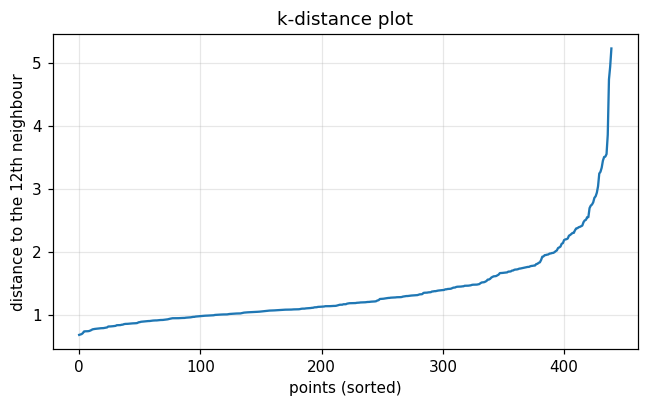

eps=1.8: clusters=1, noise=27
eps=2.0: clusters=1, noise=17
eps=2.2: clusters=1, noise=11
eps=2.5: clusters=1, noise=7
eps=3.0: clusters=1, noise=3


In [11]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

min_samples = 2 * Xs.shape[1]   # 12
kd = np.sort(NearestNeighbors(n_neighbors=min_samples)
             .fit(Xs).kneighbors(Xs)[0][:, -1])

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(kd); ax.set_xlabel("points (sorted)")
ax.set_ylabel(f"distance to the {min_samples}th neighbour"); ax.set_title("k-distance plot")
plt.tight_layout(); plt.show()

for eps in [1.8, 2.0, 2.2, 2.5, 3.0]:
    lab = DBSCAN(eps=eps, min_samples=min_samples).fit(Xs).labels_
    nclu = len(set(lab)) - (1 if -1 in lab else 0)
    print(f"eps={eps}: clusters={nclu}, noise={int((lab==-1).sum())}")

**The result: for *every* `eps`, DBSCAN finds exactly one cluster plus noise points.** That is not a bug, it is the correct answer to a wrongly posed question. The k-distance plot has **no sharp knee** — the density falls off continuously. Our data are (after log and z-score) **one single connected blob of varying density**, not a system of dense islands in empty space. DBSCAN's underlying assumption is violated.

The lesson: the choice of algorithm is a **model assumption about the shape of the clusters**. k-means/GMM ("a cluster is a compact centre / a Gaussian bell") fit here; DBSCAN ("a cluster is a density island") does not. Using a method whose assumption the data violate does not give you a worse result — it gives you a meaningless one.

## 7 · Hierarchical (Ward) + dendrogram

Ward linkage (script 2.8) merges bottom-up the two clusters whose fusion increases the WCSS the least — conceptually the agglomerative sister of k-means. The advantage: the **dendrogram** shows the cluster structure at *all* resolutions simultaneously; the height of the fusions ($k$ = the number of branches a horizontal line cuts) makes visible which number of clusters is "natural".

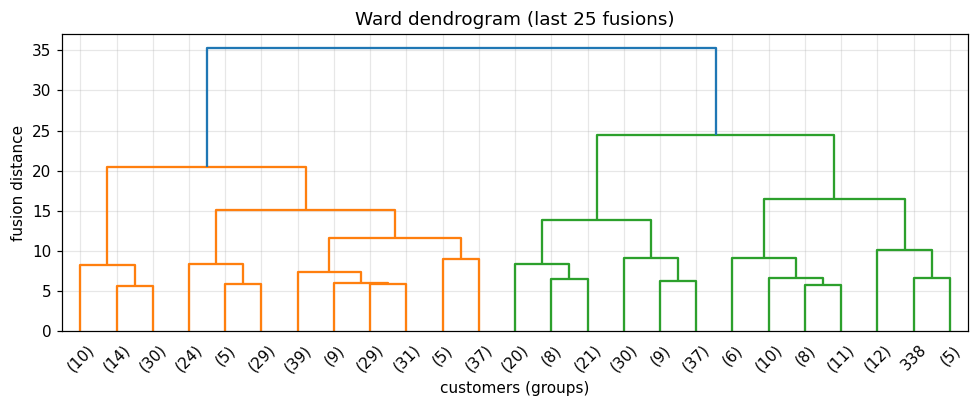

k=2: silhouette=0.258  ARI(channel)=0.539
k=3: silhouette=0.255  ARI(channel)=0.549
k=4: silhouette=0.202  ARI(channel)=0.390


In [12]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

Zl = linkage(Xs, method="ward")
fig, ax = plt.subplots(figsize=(9, 3.8))
dendrogram(Zl, truncate_mode="lastp", p=25, ax=ax, color_threshold=0.7*Zl[:,2].max())
ax.set_title("Ward dendrogram (last 25 fusions)")
ax.set_xlabel("customers (groups)"); ax.set_ylabel("fusion distance")
plt.tight_layout(); plt.show()

for k in (2, 3, 4):
    lab = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(Xs)
    print(f"k={k}: silhouette={silhouette_score(Xs,lab):.3f}  "
          f"ARI(channel)={adjusted_rand_score(channel,lab):.3f}")

The largest jump in distance in the dendrogram lies at the cut into **two** main branches — the same two-way split as with k-means and the GMM. A second, smaller jump supports $k=3$. The methods therefore agree about the *coarse* structure and only argue about the fine resolution.

## 8 · Validation: internal vs. external criterion

Now the core of the module — clustering is unsupervised, so we need criteria for "good":

- **Internal** (from $X$ alone): the **silhouette** (↑), **Davies-Bouldin** (↓), **Calinski-Harabasz** (↑). They measure compactness and separation without a ground truth.
- **External** (against the held-back `Channel` truth): the **adjusted Rand index** (ARI) — it measures the agreement of two partitions, corrected for chance (0 = random, 1 = identical). That is the honest test: *has the method rediscovered the real Horeca/retail structure?*

In [13]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

def scores(lab):
    ok = len(set(lab) - {-1}) > 1
    return dict(
        Silhouette=silhouette_score(Xs, lab) if ok else np.nan,
        DaviesBouldin=davies_bouldin_score(Xs, lab) if ok else np.nan,
        CalinskiHarabasz=calinski_harabasz_score(Xs, lab) if ok else np.nan,
        ARI_Channel=adjusted_rand_score(channel, lab))

labels = {
    "kMeans k=2":  KMeans(2, n_init=10, random_state=RNG).fit_predict(Xs),
    "GMM k=2 full": gmm2.predict(Xs),
    "GMM k=4 (BIC)": gmm_bic.predict(Xs),
    "Ward k=2":    AgglomerativeClustering(2, linkage="ward").fit_predict(Xs),
    "DBSCAN eps=2.5": DBSCAN(eps=2.5, min_samples=12).fit_predict(Xs),
}
table = pd.DataFrame({name: scores(l) for name, l in labels.items()}).T
table.round(3)

,Silhouette,DaviesBouldin,CalinskiHarabasz,ARI_Channel
kMeans k=2,0.290,1.352,189.050,0.514
GMM k=2 full,0.266,1.391,165.420,0.622
GMM k=4 (BIC),0.172,2.341,75.726,0.391
Ward k=2,0.258,1.600,134.624,0.539
DBSCAN eps=2.5,NaN,NaN,NaN,-0.016


**Read this table closely — it is the result of the project:**

1. **The GMM (k=2, full) wins on the ARI (about 0.62)** and beats k-means (about 0.51) and Ward (about 0.54) *clearly*. Why? The true segments are **elliptical and of different size and elongation** (log-normal spending). k-means forces spherical clusters of equal size and cuts the transition zone in a geometrically wrong place; the GMM with full covariance adapts to the shape. **The more flexible shape model discovers the business logic most faithfully.**
2. **The internal and the external criterion can diverge.** GMM k=4 has the best BIC but a worse ARI (it splits the two channels into sub-segments). "Statistically more components" is not the same as "better for the business question". You have to know *which* question you are asking.
3. **DBSCAN** collapses to *one* cluster (plus noise), so the internal measures are not even defined (NaN — the silhouette needs at least 2 clusters). Its ARI of about 0 confirms it: it has **not** found the structure.

No criterion is sufficient on its own: the silhouette measures geometry, the BIC measures likelihood parsimony, the ARI measures agreement with an external truth. A practitioner triangulates.

## 9 · Business interpretation: naming the segments

A clustering is only worth something once you understand the clusters *substantively*. We take the winning solution (GMM k=2) and describe the segments by their **median spending per category** (back in interpretable money space) as well as by their composition according to the true `Channel`.

Median annual spending per segment (monetary units):
           Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen
Segment                                                                
0        10272.0  1992.0   2506.0  2282.0             338.0       782.0
1         5540.0  7482.0  11722.0   973.0            4915.0      1339.0

Cross-tabulation of segment against the true channel:
Channel  Horeca  Retail
Segment                
0           263      11
1            35     131


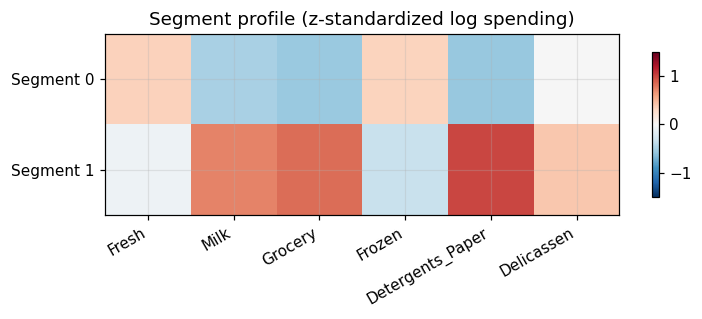

In [14]:
lab = gmm2.predict(Xs)
# Relabel the clusters so that cluster 0 is the Horeca-heavy one (for comparability)
if df.loc[lab==0, "Detergents_Paper"].median() > df.loc[lab==1, "Detergents_Paper"].median():
    lab = 1 - lab

prof = df[FEATURES].copy(); prof["Segment"] = lab
med = prof.groupby("Segment")[FEATURES].median().round(0)
print("Median annual spending per segment (monetary units):"); print(med)
print("\nCross-tabulation of segment against the true channel:")
print(pd.crosstab(pd.Series(lab, name="Segment"),
                  pd.Series(np.where(channel==0,"Horeca","Retail"), name="Channel")))

fig, ax = plt.subplots(figsize=(7, 3))
im = ax.imshow(scaler.transform(np.log1p(med.values)), cmap="RdBu_r",
               aspect="auto", vmin=-1.5, vmax=1.5)
ax.set_xticks(range(6)); ax.set_xticklabels(FEATURES, rotation=30, ha="right")
ax.set_yticks([0, 1]); ax.set_yticklabels(["Segment 0", "Segment 1"])
ax.set_title("Segment profile (z-standardized log spending)")
fig.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout(); plt.show()

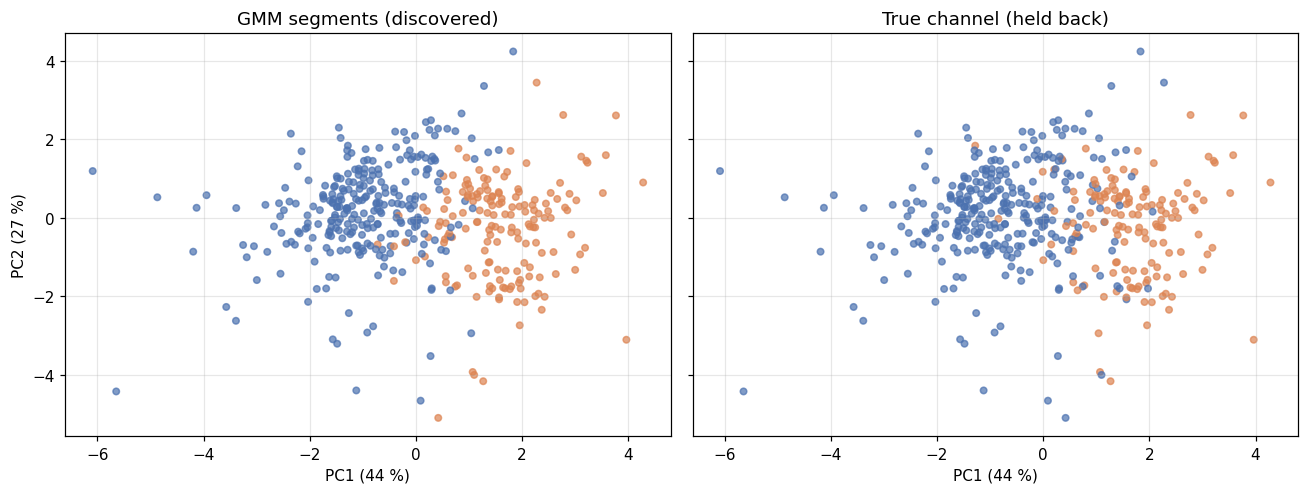

In [15]:
# The final view: PCA projection, discovered segments on the left, true channel on the right
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True, sharey=True)
a1.scatter(Z[:,0], Z[:,1], c=np.where(lab==0,"#4C72B0","#DD8452"), s=18, alpha=0.7)
a1.set_title("GMM segments (discovered)")
a2.scatter(Z[:,0], Z[:,1], c=np.where(channel==0,"#4C72B0","#DD8452"), s=18, alpha=0.7)
a2.set_title("True channel (held back)")
for a in (a1, a2): a.set_xlabel(f"PC1 ({evr[0]*100:.0f} %)")
a1.set_ylabel(f"PC2 ({evr[1]*100:.0f} %)")
plt.tight_layout(); plt.show()

**The two segments, in words:**

- **Segment 0 — "gastronomy / Horeca"**: high `Fresh` and `Frozen` spending, low `Grocery`/`Detergents_Paper`. Restaurants, cafés, hotels — they buy fresh and frozen goods, hardly any supermarket assortment. Predominantly channel = Horeca.
- **Segment 1 — "retail"**: high `Milk`, `Grocery`, `Detergents_Paper` — the supermarket basket with durable goods and non-food. Predominantly channel = retail.

The PCA maps on the left and right show it immediately: the segments found *purely from the spending* largely coincide with the held-back `Channel` truth — with a genuine transition zone in the middle (mixed businesses) that the soft GMM assignment correctly marks as "uncertain".

**The business value:** without surveying its customers, the distributor can align logistics (fresh vs. dry storage), assortment and marketing per segment — and treat the transition customers specifically as a cross-selling opportunity.

## 10 · Conclusion

| Question | The answer in this project |
|---|---|
| How many segments? | Coarsely **2** (Horeca vs. retail) — consistent across k-means, GMM and Ward; at a finer grain the BIC points to about 4 sub-segments. |
| Which method? | The **GMM with full covariance** — the highest ARI, because elliptical clusters match the log-normal spending structure and soft assignments capture the transition zone. |
| Why not DBSCAN? | The data are *one* dense blob of varying density, not separated density islands — DBSCAN's assumption is violated. |
| Validated how? | Internally (silhouette/DB/CH) **and** externally (ARI against the held-back `Channel`); both together, never one alone. |

**The core message of the module:** unsupervised learning does not deliver *the* truth, but an answer that depends on your **assumptions about cluster shape** (the choice of algorithm), your **preprocessing** (log/z-score) and your **quality criterion**. Competence here means: choosing those assumptions deliberately, recognizing when they are violated (DBSCAN!) and triangulating the results of several methods against an external criterion.